Found 32480 images belonging to 29 classes.
Found 9280 images belonging to 29 classes.
Model: "model_24"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_27 (InputLayer)       [(None, 128, 128, 3)]     0         
                                                                 
 conv2d_85 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 max_pooling2d_74 (MaxPooli  (None, 64, 64, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_86 (Conv2D)          (None, 64, 64, 64)        18496     
                                                                 
 max_pooling2d_75 (MaxPooli  (None, 32, 32, 64)        0         
 ng2D)                                                           
                                     

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


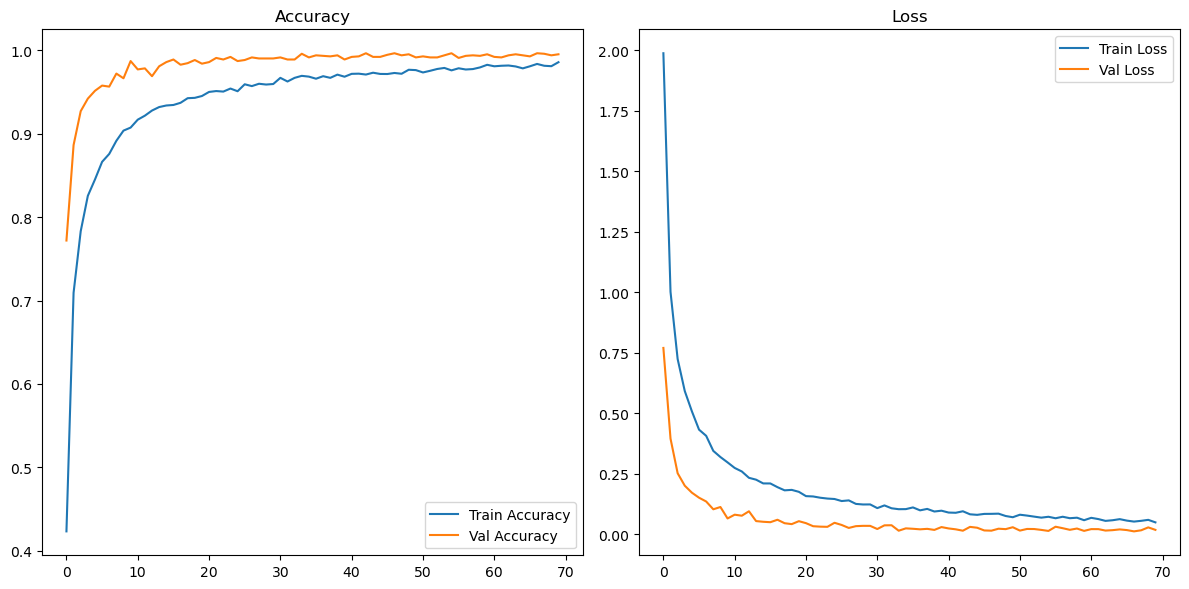

290/290 [==============================] - 89s 306ms/step
Classification Report:
               precision    recall  f1-score   support

           0       0.03      0.03      0.03       320
           1       0.04      0.04      0.04       320
           2       0.02      0.02      0.02       320
           3       0.03      0.03      0.03       320
           4       0.03      0.03      0.03       320
           5       0.02      0.02      0.02       320
           6       0.04      0.04      0.04       320
           7       0.05      0.05      0.05       320
           8       0.02      0.02      0.02       320
           9       0.02      0.03      0.02       320
          10       0.06      0.06      0.06       320
          11       0.03      0.03      0.03       320
          12       0.04      0.04      0.04       320
          13       0.02      0.03      0.02       320
          14       0.04      0.04      0.04       320
          15       0.03      0.03      0.03       320

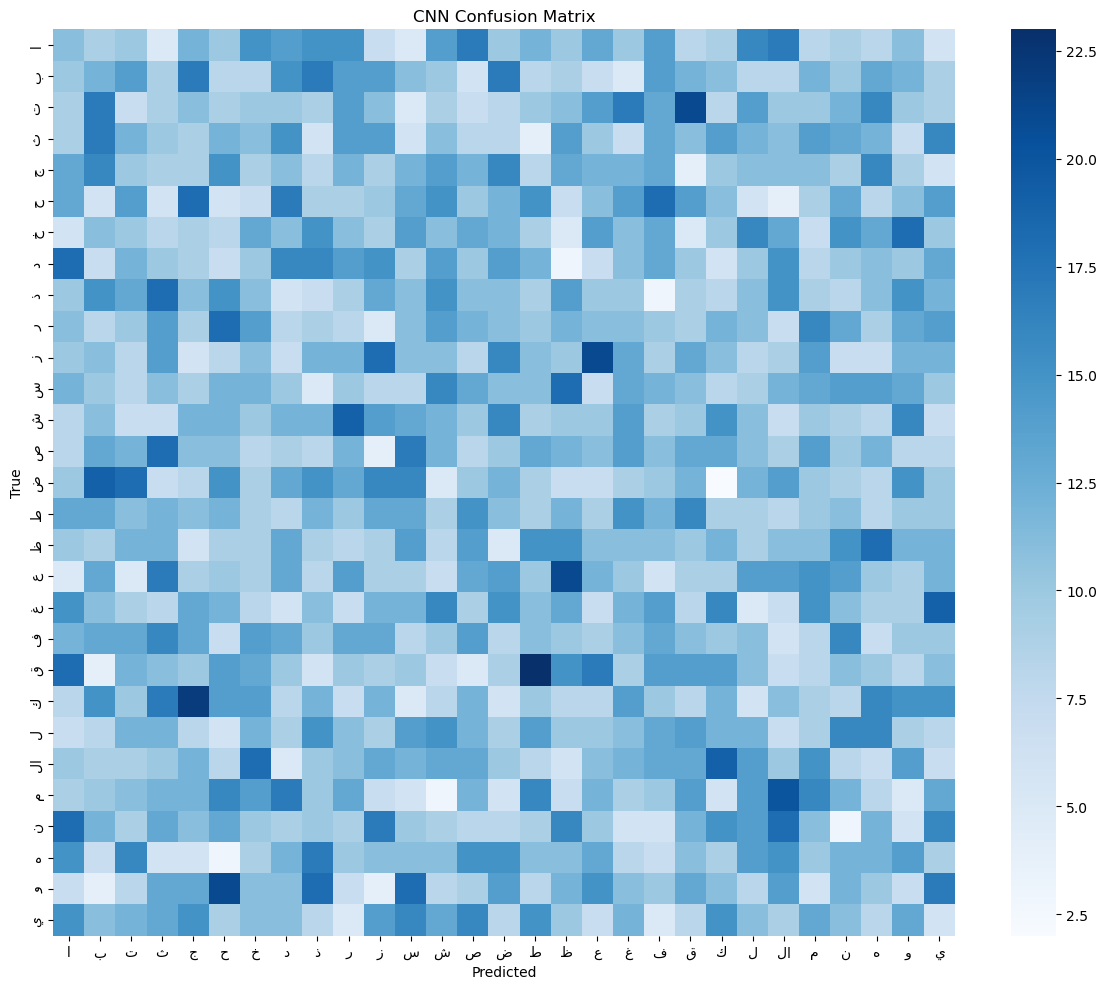

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns

# -------- CNN Model Definition --------
def build_cnn_model(input_shape=(128, 128, 3), num_classes=29):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=x)
    return model

# -------- Data Generators --------
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, zoom_range=0.2, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_dir = r'E:\new_dataset\2000\Data_Devided\train'
val_dir = r'E:\new_dataset\2000\Data_Devided\val'

train_generator = train_datagen.flow_from_directory(train_dir, target_size=(128, 128), batch_size=32, class_mode='categorical')
val_generator = val_datagen.flow_from_directory(val_dir, target_size=(128, 128), batch_size=32, class_mode='categorical')

# -------- Train CNN Model --------
model = build_cnn_model(input_shape=(128, 128, 3), num_classes=29)
model.summary()

model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(train_generator, epochs=70, steps_per_epoch=300, validation_data=val_generator, validation_steps=50)

# -------- Save Model --------
model.save('arabic_character_cnn_model.h5')

# -------- Plot Training History --------
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('cnn_training_plot.png')
plt.show()

# -------- Evaluation --------
val_steps = val_generator.samples // val_generator.batch_size
y_true = val_generator.classes
y_pred = np.argmax(model.predict(val_generator, steps=val_steps), axis=-1)

# Ensure equal length
if len(y_true) != len(y_pred):
    y_true = y_true[:len(y_pred)]

# Metrics
print("Classification Report:\n", classification_report(y_true, y_pred))
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1 Score:  {f1_score(y_true, y_pred, average='weighted'):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=val_generator.class_indices.keys(), yticklabels=val_generator.class_indices.keys())
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png')
plt.show()


In [ ]:
rack soulation in generative ai/data managment/power bi/ai cenertive\n8n

Found 9280 images belonging to 29 classes.
290/290 [==============================] - 76s 263ms/step
Classification Report:
               precision    recall  f1-score   support

           ا       1.00      1.00      1.00       320
           ب       0.98      0.99      0.99       320
           ت       0.99      0.97      0.98       320
           ث       0.98      1.00      0.99       320
           ج       1.00      1.00      1.00       320
           ح       1.00      1.00      1.00       320
           خ       1.00      1.00      1.00       320
           د       1.00      0.99      1.00       320
           ذ       1.00      0.99      1.00       320
           ر       0.99      1.00      1.00       320
           ز       0.99      0.99      0.99       320
           س       1.00      1.00      1.00       320
           ش       1.00      1.00      1.00       320
           ص       0.99      1.00      0.99       320
           ض       0.99      1.00      1.00       320
          

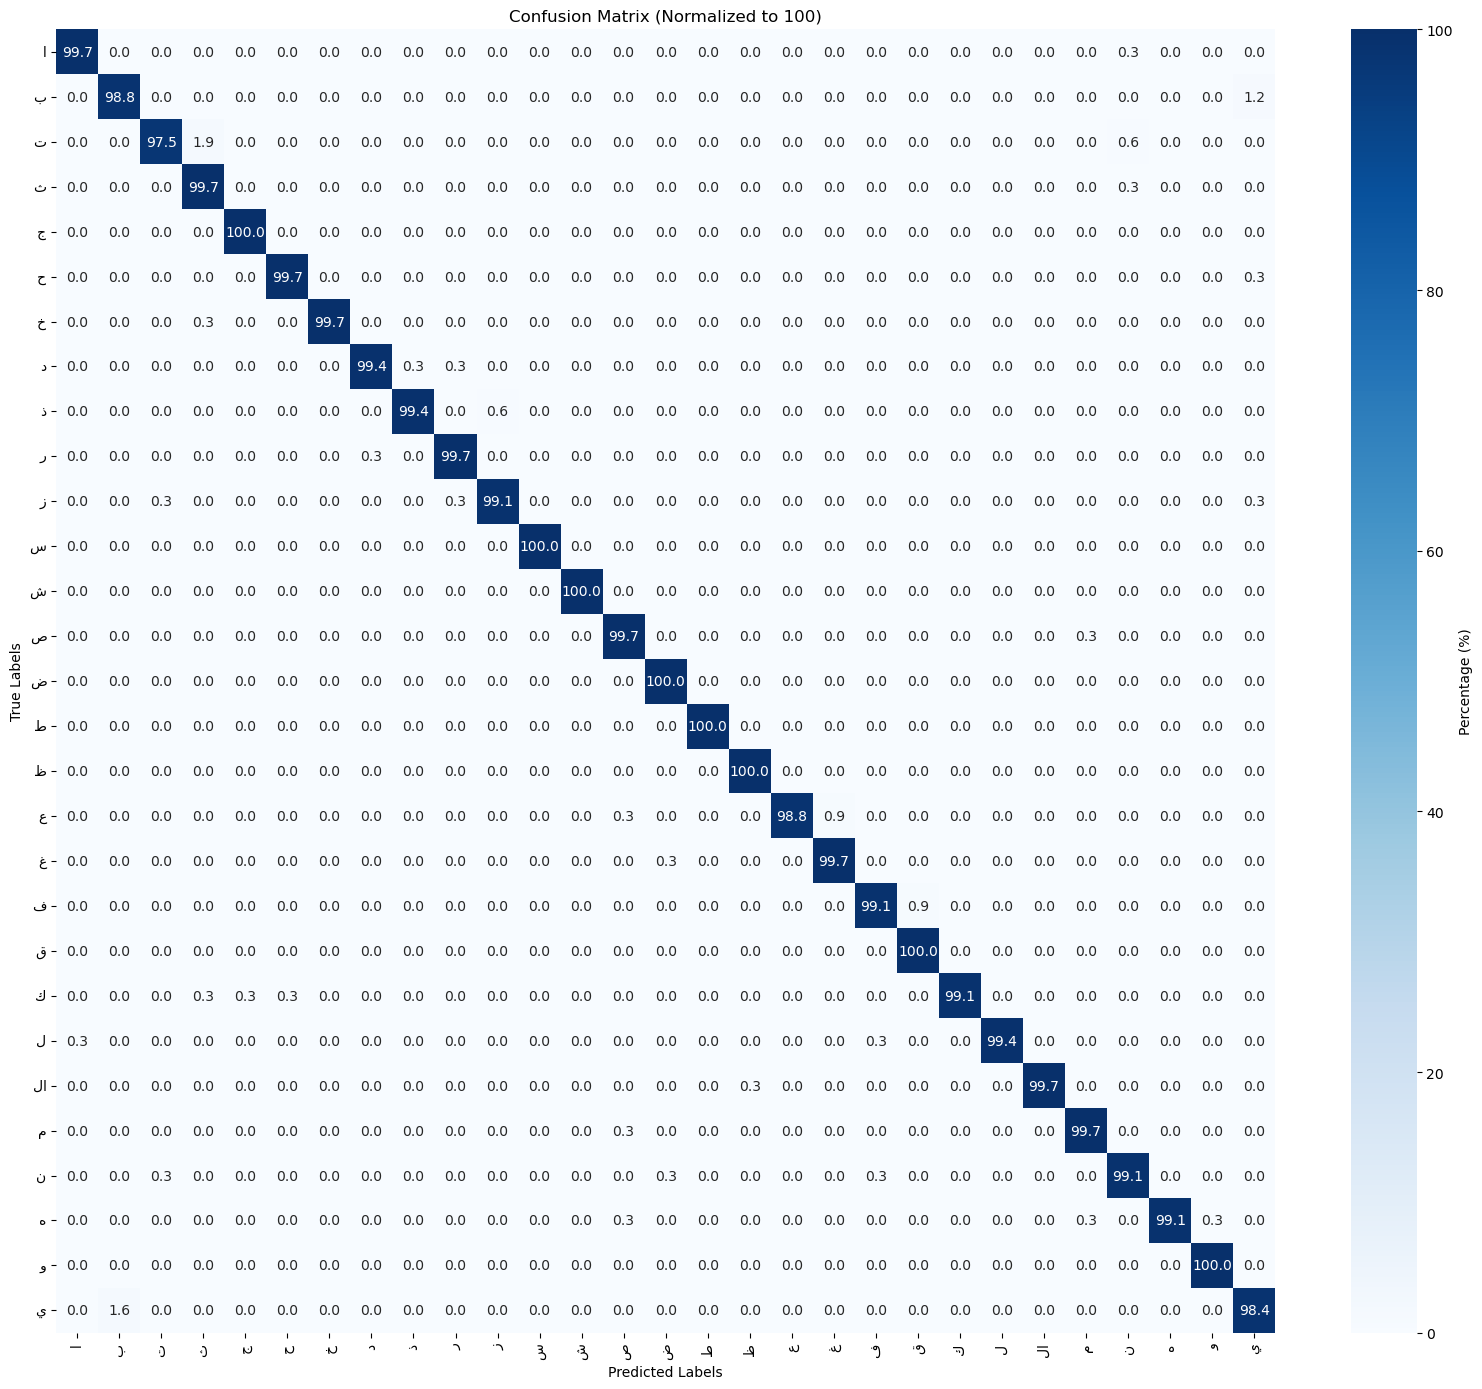

In [45]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# --- Recreate validation generator with shuffle=False ---
val_generator_reset = val_datagen.flow_from_directory(
    val_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False)

# --- True labels and predictions ---
y_true = val_generator_reset.classes
y_pred_probs = model.predict(val_generator_reset, steps=np.ceil(val_generator_reset.samples / val_generator_reset.batch_size))
y_pred = np.argmax(y_pred_probs, axis=1)

# --- Class labels ---
class_indices = val_generator_reset.class_indices
class_labels = list(class_indices.keys())

# --- Classification Report (text) ---
report_text = classification_report(y_true, y_pred, target_names=class_labels)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Print to console
print("Classification Report:\n", report_text)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# --- Save classification report as image ---
fig, ax = plt.subplots(figsize=(12, 10))
ax.axis('off')
report_full = f"Classification Report\n\n{report_text}\nAccuracy: {accuracy:.4f}\nPrecision: {precision:.4f}\nRecall: {recall:.4f}\nF1 Score: {f1:.4f}"
ax.text(0, 1, report_full, verticalalignment='top', fontsize=12, family='monospace')
plt.tight_layout()
plt.savefig("cnn_classification_report.png", dpi=300)
plt.close()

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
cm_percentage = np.nan_to_num(cm_percentage)

plt.figure(figsize=(16, 14))
sns.heatmap(cm_percentage, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Percentage (%)'})
plt.title("Confusion Matrix (Normalized to 100)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("cnn_confusion_matrix_100scale.png")
plt.show()
